# Why? 

Why use streams as inferential tools? here are some reasons! 

1. More or less, we can probe the acceleration field almost directly. 

On-sky accelerations are not measureable. Let me cite the work of [Timothy Brandt (2021)](https://iopscience.iop.org/article/10.3847/1538-4365/abf93c). 

Here's the title and the first sentence of the abstract: "We present a cross-calibration of Hipparcos and Gaia EDR3 intended to identify astrometrically accelerating stars and to fit orbits to stars with faint, massive companions"


Right there, we immediately give away to the fact that we don't expect to see such a change from the galactic field.

What is the acceleration we'd expect for a star the local solar neighborhood from the galactic field? 

In [1]:
from astropy import units as u 
from astropy import coordinates 
import numpy as np 
import agama
import pathlib
from matplotlib import pyplot as plt
agama.setUnits(length=1,mass=1,velocity=1)

In [2]:
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{txfonts}",
})

In [3]:
def local_vcirc(potential, R, z=0.0):
    """Circular speed from radial force: v_c^2 = R * dPhi/dR = -R * a_R."""
    xyz = np.array([[R, 0.0, z]])
    acc = np.asarray(potential.force(xyz))[0]   # ax, ay, az
    aR = acc[0]                                 # at y=0, radial direction is +x
    return np.sqrt(np.maximum(0.0, -R * aR))

def sample_local_disk_ic(
    potential,
    N=10000,
    R0=8.2, z0=0.02,        # Sun position [kpc]
    radius_pc=200,          # local neighborhood size [pc]
    sigR=35.0, sigphi=25.0, sigz=20.0,  # km/s dispersions
    asym_drift=12.0,        # km/s lag vs circular speed
    seed=42
):
    rng = np.random.default_rng(seed)
    rmax = radius_pc / 1000.0  # kpc

    # Uniform in sphere around Sun
    u = rng.random(N)
    costh = rng.uniform(-1, 1, N)
    phi = rng.uniform(0, 2*np.pi, N)
    r = rmax * u**(1/3)
    sinth = np.sqrt(1 - costh**2)

    dx = r * sinth * np.cos(phi)
    dy = r * sinth * np.sin(phi)
    dz = r * costh

    x = R0 + dx
    y = dy
    z = z0 + dz

    # Cylindrical coordinates for velocity model
    R = np.sqrt(x*x + y*y)
    phic = np.arctan2(y, x)

    # Local circular speed from potential
    vc = np.array([local_vcirc(potential, Ri, zi) for Ri, zi in zip(R, z)])

    # Gaussian disk velocity ellipsoid in cylindrical frame
    vR = rng.normal(0.0, sigR, N)
    vz = rng.normal(0.0, sigz, N)
    vphi = vc - asym_drift + rng.normal(0.0, sigphi, N)

    # Convert to Cartesian
    vx = vR*np.cos(phic) - vphi*np.sin(phic)
    vy = vR*np.sin(phic) + vphi*np.cos(phic)

    pos = np.column_stack((x, y, z))
    vel = np.column_stack((vx, vy, vz))
    return pos, vel


In [4]:
fname = agama.__path__[0] + "/data/" + "McMillan11_convenient.ini"
potential = agama.Potential(fname)
nparticles = int(1e2)
xSun = -8.2
zSun = 20e-3
pos, vel = sample_local_disk_ic(potential, N=nparticles, radius_pc=200,R0=xSun,z0=zSun)

In [5]:
# lets integrate these orbits for one thousand years! 
unitT = u.s * u.kpc / u.km 
integration_time = 1e5*u.year
integration_time=integration_time.to(unitT).value

In [6]:
initial_conds = np.hstack((pos,vel))

In [7]:
filename_axi      = 'McMillan11_convenient.ini'
potential_path = agama.__path__[0] + "/data/" + filename_axi
potential = agama.Potential(potential_path)
timestamps,orbits = agama.orbit(ic=initial_conds,potential=potential,time=integration_time,trajsize=100,separateTime=True)

100 orbits complete (100000 orbits/s)


In [8]:
colors=np.random.random_sample(size=(nparticles,3))

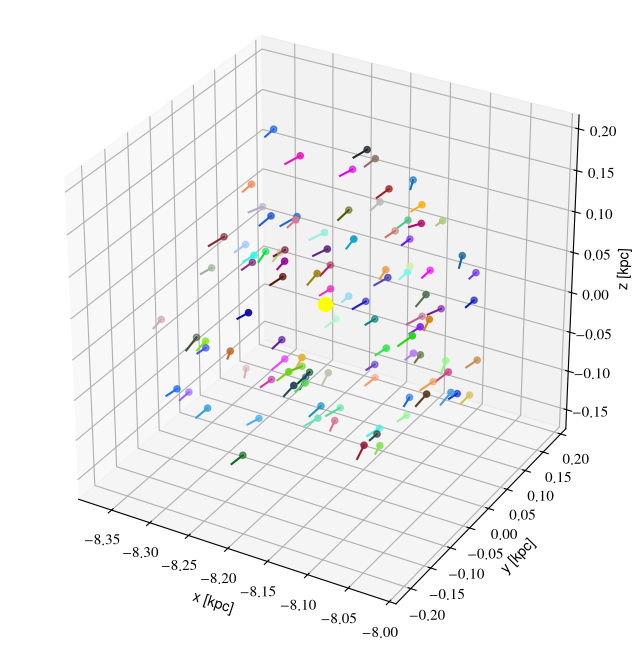

In [9]:
fig=plt.figure(figsize=(8,8))
axis=fig.add_axes(111,projection="3d");
axis.scatter(xSun,0,zSun,c="yellow",s=100);
axis.set(xlabel='x [kpc]', ylabel="y [kpc]", zlabel="z [kpc]",box_aspect=(1,1,1))
axis.scatter(pos[:,0],pos[:,1],pos[:,2],c=colors);
handles = [ ]
for n in range(nparticles):
    handles.append(axis.plot(orbits[n,:,0],orbits[n,:,1],orbits[n,:,2],color=colors[n]))

In [10]:
# okay, what's the differenc ein the proper motions? 
frame = coordinates.Galactocentric
c = coordinates.SkyCoord(x=pos[:,0]*u.kpc,y=pos[:,1]*u.kpc,z=pos[:,2]*u.kpc,v_x=vel[:,0]*u.km/u.s,v_y=vel[:,1]*u.km/u.s,v_z=vel[:,2]*u.km/u.s,
                         frame=frame,z_sun=zSun*u.kpc,galcen_distance=np.abs(xSun)*u.kpc)

In [13]:
d = 8*u.kpc
vc = 220*u.km/u.s
delta_theta = 20*u.microarcsecond
delta_theta=delta_theta.to(u.radian).value
T = (d/vc) * np.sqrt(2*delta_theta)
T.to(u.year)

<Quantity 495.14376355 yr>

In [14]:
# now, what's the angular displacement during the gaia baseline? 
T = 10*u.year
deltatheta=T**2 * vc**2 / d**2 / (2)
deltatheta=deltatheta.to(u.dimensionless_unscaled) 
delta_theta/deltatheta


<Quantity 2451.67346584>